## Figure 8

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/fig8_fearcond_control/`: control networks, 30 seeds
- `out/fig8_fearcond_archt/`: simulated ArchT (reduced feedback), 30 seeds

Experimental data in panels b, e are digitized from Krabbe et al. (2019), Nat. Neurosci. 22, Figs 7g, 6f.

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import ptitprince as pt

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.patches import Patch, PathPatch, Rectangle

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})

from bcp.analysis import HydraRunOutput

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())

#### Directory setup

In [19]:
control_dir = repo_root / "out" / "fig8_fearcond_control"
archt_dir = repo_root / "out" / "fig8_fearcond_archt"

fig8_dir = repo_root / "figures" / "fig8"
fig8_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [20]:
SEED = 0

cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_closedloop = '#F49F1E'
color_exp = '#00B5B7'
color_control = 'gray'

linewidth = 1.0

### Panels b, e: Krabbe et al. (2019) data

In [21]:
# Fig 7g: freezing and VIP US response [%] per pairing (mean, upper SEM bound)
freezing_mean = np.array([0.1360544217687075, 9.523809523809526, 24.48979591836735, 48.43537414965987, 43.673469387755105,
                          87.89115646258504, 72.24489795918367, 73.46938775510205, 58.23129251700681, 74.421768707483])
freezing_sem = np.array([0.1360544217687075, 17.687074829931973, 37.55102040816327, 57.823129251700685, 52.925170068027214,
                         92.10884353741497, 83.26530612244899, 79.31972789115648, 68.29931972789116, 81.08843537414967]) - freezing_mean
us_resp_mean = np.array([90.06802721088437, 63.80952380952382, 42.721088435374156, 36.59863945578232, 31.292517006802726,
                         29.38775510204082, 27.482993197278915, 17.142857142857146, 23.673469387755105, 15.918367346938776])
us_resp_sem = np.array([92.92517006802721, 66.66666666666667, 46.93877551020409, 40.68027210884354, 35.64625850340136,
                        34.14965986394558, 32.10884353741497, 20.816326530612248, 27.2108843537415, 21.360544217687078]) - us_resp_mean

# Fig 6f: freezing [%] as [mean, median, lower IQR, upper IQR, lower whisker, upper whisker]
pre_cs_exp = [10.568031704095112, 9.90752972258917, 4.29326287978864, 16.050198150594454, 2.311756935270806, 21.730515191545578]
pre_cs_control = [18.560105680317044, 14.06869220607662, 10.634081902245708, 23.051519154557464, 4.557463672391018, 41.54557463672391]
post_cs_exp = [26.221928665786, 18.163804491413476, 7.9920739762219295, 50.66050198150595, 3.1043593130779397, 62.81373844121533]
post_cs_control = [49.47159841479525, 43.92338177014531, 25.561426684280054, 76.55217965653898, 3.3685601056803174, 94.1215323645971]

In [22]:
figsize_data_performance = (5.8*cm, 2.8*cm)
figsize_data_boxplot = (5.0*cm, 2.8*cm)

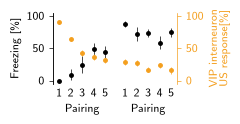

In [23]:
fig = MultiPanel(grid=[2], figsize=figsize_data_performance, hspace=0, wspace=0)
x = np.arange(1, 6)

for day, ax_freeze in enumerate(fig.panels):
    ax_us = ax_freeze.twinx()
    days = slice(5 * day, 5 * day + 5)
    ax_freeze.errorbar(x, freezing_mean[days], yerr=freezing_sem[days], fmt='o', color='black',
                       capsize=0, markersize=2.5, elinewidth=0.5)
    ax_us.errorbar(x, us_resp_mean[days], yerr=us_resp_sem[days], fmt='o', color=color_closedloop,
                   capsize=0, markersize=2.5, elinewidth=0.5)

    for ax in (ax_freeze, ax_us):
        ax.spines['bottom'].set_visible(False)
        ax.set_xlim(0.5, 5.5)
        ax.set_ylim(-5, 105)
        ax.tick_params(axis='x', length=0)
    ax_freeze.set_xticks(x)
    ax_freeze.set_xticklabels([str(i) for i in x])
    ax_freeze.set_xlabel('Pairing')

    if day == 0:
        ax_freeze.set_yticks([0, 50, 100])
        ax_freeze.set_yticklabels(['0', '50', '100'])
        ax_freeze.set_ylabel(r'Freezing [\%]')
        ax_freeze.spines['right'].set_visible(False)
        ax_us.spines['right'].set_visible(False)
        ax_us.set_yticks([])
    else:
        ax_freeze.spines['left'].set_visible(False)
        ax_freeze.set_yticks([])
        ax_us.spines['left'].set_visible(False)
        ax_us.spines['right'].set_visible(True)
        ax_us.spines['right'].set_color(color_closedloop)
        ax_us.tick_params(axis='y', colors=color_closedloop)
        ax_us.set_yticks([0, 50, 100])
        ax_us.set_yticklabels(['0', '50', '100'])
        ax_us.set_ylabel('VIP interneuron\n' + r'US response[\%]', color=color_closedloop)

plt.savefig(fig8_dir / 'b_data_freezing_us_response.pdf', bbox_inches='tight')
plt.show()

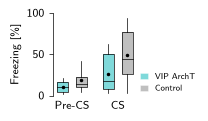

In [24]:
def draw_custom_boxplot(ax, position, data, color, width=0.6):
    mean, median, lower_IQR, upper_IQR, lower_whisker, upper_whisker = data
    ax.add_patch(Rectangle((position - width / 2, lower_IQR), width, upper_IQR - lower_IQR,
                           fill=True, color=color, alpha=0.5, linewidth=0))
    ax.add_patch(Rectangle((position - width / 2, lower_IQR), width, upper_IQR - lower_IQR,
                           fill=False, color='black', linewidth=0.5))
    ax.plot([position - width / 2, position + width / 2], [median, median], 'k-', linewidth=0.5)
    ax.plot([position, position], [lower_IQR, lower_whisker], 'k-', linewidth=0.5)
    ax.plot([position, position], [upper_IQR, upper_whisker], 'k-', linewidth=0.5)
    ax.plot(position, mean, 'ko', markersize=1.5)


fig = MultiPanel(grid=[2], figsize=figsize_data_boxplot, hspace=0, wspace=0)
for ax, (exp, control), label in zip(fig.panels, [(pre_cs_exp, pre_cs_control), (post_cs_exp, post_cs_control)],
                                     ['Pre-CS', 'CS']):
    ax.spines['bottom'].set_visible(False)
    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks([])
    ax.set_xlabel(label)
    ax.set_ylim(0, 100)
    draw_custom_boxplot(ax, 0, exp, color_exp)
    draw_custom_boxplot(ax, 1, control, color_control)

fig.panels[0].set_yticks([0, 50, 100])
fig.panels[0].set_yticklabels(['0', '50', '100'])
fig.panels[0].set_ylabel(r'Freezing [\%]')
fig.panels[1].spines['left'].set_visible(False)
fig.panels[1].set_yticks([])
fig.panels[1].legend(handles=[Patch(facecolor=color_exp, alpha=0.5, label='VIP ArchT'),
                              Patch(facecolor=color_control, alpha=0.5, label='Control')],
                     loc=(1, 0), frameon=False, ncol=1, fontsize=6, handlelength=1.0)

plt.savefig(fig8_dir / 'e_data_boxplot.pdf', bbox_inches='tight')
plt.show()

### Load runs

In [25]:
CS_WINDOW = slice(0, 4000)       # CS presentation (1 ms steps)
US_WINDOW = slice(4000, 6000)    # US presentation
PRE_CS_WINDOW = slice(6000, None)  # after the CS in CS-only test trials
TEST_PAIRING = 3                 # panel f: test after this many pairings

In [ ]:
def load_condition(path):
    us_fb, cl_freeze_cs, ol_cs, ol_pre_cs = [], [], [], []
    for run_path in sorted(p for p in path.iterdir() if p.is_dir()):
        r = HydraRunOutput(run_path).load_pickle('results.pkl')
        us_fb.append(r['fb'][1:, US_WINDOW].mean(1))
        cl_freeze_cs.append(r['CL_freeze'][1:, CS_WINDOW].mean(1))
        ol_cs.append(r['OL_freeze'][TEST_PAIRING, CS_WINDOW].mean())
        ol_pre_cs.append(r['OL_freeze'][TEST_PAIRING, PRE_CS_WINDOW].mean())
        del r
    return {'us_fb': np.stack(us_fb), 'cl_freeze_cs': np.stack(cl_freeze_cs),
            'ol_cs': np.array(ol_cs), 'ol_pre_cs': np.array(ol_pre_cs)}


control = load_condition(control_dir)
archt = load_condition(archt_dir)
print('networks:', len(control['ol_cs']), len(archt['ol_cs']))

networks: 30 30


### Panel d: freezing and US feedback during learning

In [27]:
figsize_performance = (5.8*cm, 2.8*cm)

/var/folders/hv/pkkqx_mx7s12wnhdkf46t2qr0000gn/T/ipykernel_50269/3723608055.py:2: RuntimeWarning: invalid value encountered in divide
  us_fb = control['us_fb'] / control['us_fb'].max(axis=1)[:, None, :]


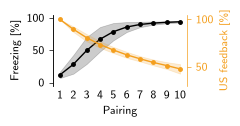

In [28]:
# US feedback normalized to each neuron's maximum across pairings, averaged over neurons, in %
us_fb = control['us_fb'] / control['us_fb'].max(axis=1)[:, None, :]
us_fb = 100 * np.nanmean(us_fb, axis=-1)  # [networks, pairings]
freeze = control['cl_freeze_cs']
x = np.arange(1, 11)

fig, ax1 = plt.subplots(1, 1, figsize=figsize_performance)
ax2 = ax1.twinx()
for ax in (ax1, ax2):
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='x', length=0)
ax2.spines['right'].set_visible(True)

ax1.set_xticks(x)
ax1.set_xticklabels([str(i) for i in x])
ax1.set_xlabel('Pairing')
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(-0.05, 1.05)
ax1.set_yticks([0, 0.5, 1])
ax1.set_yticklabels(['0', '50', '100'])
ax1.set_ylabel(r'Freezing [\%]')
ax2.set_ylim(30, 105)
ax2.set_yticks([50, 100])
ax2.set_yticklabels(['50', '100'])
ax2.spines['right'].set_color(color_closedloop)
ax2.tick_params(axis='y', colors=color_closedloop)
ax2.set_ylabel(r'US feedback [\%]', color=color_closedloop)

ax1.plot(x, freeze.mean(0), 'o-', color='black', markersize=2.5)
ax1.fill_between(x, freeze.mean(0) - freeze.std(0), freeze.mean(0) + freeze.std(0), color='black', alpha=0.2)
ax2.plot(x, us_fb.mean(0), 'o-', color=color_closedloop, markersize=2.5)
ax2.fill_between(x, us_fb.mean(0) - us_fb.std(0), us_fb.mean(0) + us_fb.std(0), color=color_closedloop, alpha=0.2)

plt.savefig(fig8_dir / 'd_model_freezing_us_feedback.pdf', bbox_inches='tight')
plt.show()

### Panel f: freezing after training, simulated ArchT vs control

In [29]:
figsize_raincloud = (5.8*cm, 2.8*cm)
group_order = ['Pre-CS', 'CS']
condition_colors = {'Less FB': color_exp, 'Control': color_control}
violin_width = 0.5
box_width = 0.25
point_size = 2
kde_bw = 0.3
kde_cut = 0.2


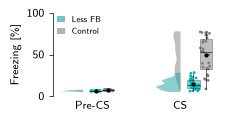

Pre-CS : Less FB 0.066, Control 0.075
CS     : Less FB 0.151, Control 0.497


In [30]:
values = {
    ('Pre-CS', 'Less FB'): archt['ol_pre_cs'], ('Pre-CS', 'Control'): control['ol_pre_cs'],
    ('CS', 'Less FB'): archt['ol_cs'], ('CS', 'Control'): control['ol_cs'],
}
df = pd.DataFrame([
    {'Value': value, 'Time': group, 'Condition': condition}
    for (group, condition), v in values.items()
    for value in v
])
np.random.seed(SEED)

fig, ax = plt.subplots(1, 1, figsize=figsize_raincloud)
pt.RainCloud(
    x='Time', y='Value', hue='Condition', data=df, ax=ax,
    order=group_order, hue_order=list(condition_colors),
    palette=list(condition_colors.values()), alpha=0.5, dodge=True,
    pointplot=False, width_box=box_width, width_viol=violin_width,
    linewidth=0.0, linecolor='black', bw=kde_bw, cut=kde_cut,
    point_size=point_size,
    box_linewidth=0.4, box_fliersize=0.5,
    box_whiskerprops={'linewidth': 0.4, 'zorder': 10, 'alpha': 1.0, 'color': 'black'},
    box_capprops={'linewidth': 0.0, 'zorder': 10, 'alpha': 1.0, 'color': 'black'},
    box_showmeans=True, box_showfliers=False,
    box_meanprops={'marker': 'o', 'markerfacecolor': 'black',
                   'markeredgecolor': 'black', 'zorder': 10, 'markersize': 2},
    box_medianprops={'color': 'black', 'linewidth': 0.4, 'zorder': 10},
)

# ptitprince 0.3.1 supplies boxprops internally and applies alpha to all lines.
for box in ax.patches:
    if isinstance(box, PathPatch):
        box.set(alpha=0.5, edgecolor='black', linewidth=0.4, zorder=10)
for line in ax.lines:
    line.set_alpha(1.0)

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['0', '50', '100'], fontsize=8)
ax.set_ylabel(r'Freezing [\%]', fontsize=8)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', length=0)
ax.set_xticks([-0.1, 0.8])
ax.set_xticklabels(group_order, fontsize=8)
ax.set_xlabel('')

handles, labels = ax.get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(0.6)
ax.legend(handles[:len(condition_colors)], labels[:len(condition_colors)],
          loc='upper left', borderaxespad=0., fontsize=6, handlelength=1.0)

plt.savefig(fig8_dir / 'f_model_freezing_archt.pdf', bbox_inches='tight')
plt.show()

for group in group_order:
    print(f"{group:7s}: Less FB {values[(group, 'Less FB')].mean():.3f}, Control {values[(group, 'Control')].mean():.3f}")
